<a href="https://colab.research.google.com/github/Abstractor-bit/GFlowNet-Alpha-Mining/blob/main/notebooks/Alpha_GFN_v1_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
GFlowNet for Formulaic Alpha Factor Mining
Author: He Hongjin (HKUST AI Major)
Date: March 2026

Goal: Generate diverse, high-IC alpha expressions using Generative Flow Networks
Building upon: Bengio et al. (2021), Alpha-GFN framework
"""

'\nGFlowNet for Formulaic Alpha Factor Mining\nAuthor: He Hongjin (HKUST AI Major)\nDate: March 2026\n\nGoal: Generate diverse, high-IC alpha expressions using Generative Flow Networks\nBuilding upon: Bengio et al. (2021), Alpha-GFN framework\n'

In [ ]:
# Cell 1: Install dependencies
!pip install yfinance pandas numpy matplotlib seaborn torch -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from datetime import datetime

print("✅ Dependencies installed successfully")

✅ Dependencies installed successfully


## Initial Setup - Dependency Analysis

**Libraries chosen & rationale:**
- `torch`: Core framework for implementing GFlowNet's forward/backward policies
- `yfinance`: Quick prototyping data source (limitation: survivorship bias, will discuss below)
- Standard stack: pandas, numpy for data manipulation

**Critical consideration for production:**
⚠️ **Data quality issue**: yfinance has known limitations:
- Survivorship bias (only currently listed stocks)
- Potential corporate action adjustments inconsistency
- Free data = not suitable for serious backtesting

**Future improvement:**
For rigorous research (especially with Prof. Pan's group), should migrate to:
- Qlib framework (used in AlphaSAGE paper)
- Proprietary data feeds (for real quant applications)
- Proper adjustment for splits, dividends, delistings

**Why starting here anyway:**
Following scientific method: establish proof-of-concept first, then scale to production-quality data. This aligns with GFlowNet literature where toy environments precede complex applications.



In [ ]:
# Cell 2: Download stock data and construct features
def prepare_alpha_data(tickers=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA'],
                       start='2020-01-01', end='2024-12-31'):
    """
    Download stock data and compute basic features for alpha generation

    Args:
        tickers: List of stock symbols
        start/end: Date range

    Returns:
        df: DataFrame with features and future returns
        feature_names: List of available feature names
    """
    print(f"Downloading data for {tickers}...")
    data = yf.download(tickers, start=start, end=end, progress=False)

    # Extract close prices and volume
    close = data['Close']
    volume = data['Volume']

    # Compute features
    features = {}
    features['close'] = close
    features['volume'] = volume
    features['return_1d'] = close.pct_change(1)
    features['return_5d'] = close.pct_change(5)
    features['return_20d'] = close.pct_change(20)
    features['volatility_5d'] = close.pct_change().rolling(5).std()
    features['volatility_20d'] = close.pct_change().rolling(20).std()
    features['volume_ratio'] = volume / volume.rolling(20).mean()

    # Compute forward returns as labels
    features['future_return'] = close.pct_change(5).shift(-5)  # 5-day forward return

    # Remove NaN values
    df = pd.DataFrame({k: v.stack() for k, v in features.items()})
    df = df.dropna()

    print(f"✅ Data ready: {len(df)} samples, {len(tickers)} stocks")
    return df, list(features.keys())[:-1]  # Exclude future_return from features

# Execute
data, feature_names = prepare_alpha_data()
print(f"Available features: {feature_names}")
data.head()

/tmp/ipykernel_613/2350936593.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end, progress=False)


✅ Data ready: 6160 samples, 5 stocks
Available features: ['close', 'volume', 'return_1d', 'return_5d', 'return_20d', 'volatility_5d', 'volatility_20d', 'volume_ratio']


close     volume  return_1d  return_5d  return_20d  \
Date       Ticker                                                            
2020-01-31 AAPL     74.608574  199588400  -0.044339  -0.027646    0.030498   
           AMZN    100.435997  311346000   0.073791   0.079006    0.058330   
           GOOGL    71.051750   43822000  -0.014764  -0.022774    0.046834   
           MSFT    161.262100   36142700  -0.014759   0.031447    0.059830   
           TSLA     43.371334  235789500   0.015231   0.151818    0.512039   

                   volatility_5d  volatility_20d  volume_ratio  future_return  
Date       Ticker                                                              
2020-01-31 AAPL         0.031370        0.017679      1.426197       0.036443  
           AMZN         0.034490        0.019235      3.859535       0.035127  
           GOOGL        0.014671        0.011616      1.356055       0.032336  
           MSFT         0.020716        0.012970      1.348840       0.080245  
           TSLA         0.043393        0.037622      0.790537       0.149869

## Data Exploration & Feature Engineering Analysis

**Dataset characteristics observed:**
```python
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(f"Total samples: {len(data)}")
print(f"Feature correlation matrix:")
print(data[feature_names].corr())


In [ ]:
# Cell 3: Alpha Expression Environment
class AlphaExpressionEnv:
    """
    Environment for generating formulaic alpha factors using GFlowNet

    State: Current expression tree (represented as list)
    Action: Add operator or feature
    Termination: Max depth reached or STOP action selected
    Reward: Information Coefficient (IC) on historical data
    """
    def __init__(self, feature_names, max_depth=5):
        self.feature_names = feature_names
        self.operators = ['+', '-', '*', '/']
        self.max_depth = max_depth

        # Action space = features + operators + STOP token
        self.action_space = feature_names + self.operators + ['STOP']
        self.n_actions = len(self.action_space)

        print(f"Environment initialized: {self.n_actions} possible actions")

    def reset(self):
        """Initialize empty expression"""
        return []

    def step(self, state, action_idx):
        """
        Execute action and return new state

        Args:
            state: Current expression (list of tokens)
            action_idx: Index of action to take

        Returns:
            new_state: Updated expression
            done: Whether episode is terminated
        """
        action = self.action_space[action_idx]
        new_state = state + [action]

        # Check termination
        done = (action == 'STOP') or (len(new_state) >= self.max_depth)

        return new_state, done

    def is_valid(self, state):
        """Check if expression is valid (simplified version)"""
        if len(state) == 0:
            return False
        # Must contain at least one feature and end with STOP
        has_feature = any(s in self.feature_names for s in state)
        return has_feature and state[-1] == 'STOP'

    def state_to_expression(self, state):
        """Convert state to readable expression string"""
        # Remove STOP token
        expr = [s for s in state if s != 'STOP']
        if len(expr) == 0:
            return "empty"
        # Simple concatenation (real implementation should build proper AST)
        return ' '.join(expr)

    def compute_reward(self, state, data):
        """
        Compute Information Coefficient (IC) as reward

        IC measures correlation between alpha predictions and future returns
        Higher absolute IC indicates better predictive power
        """
        if not self.is_valid(state):
            return 0.0

        try:
            # Simplified version: direct eval
            # Production version should use AST parser for safety
            expr = self.state_to_expression(state)

            # Map feature names to data columns
            local_vars = {feat: data[feat].values for feat in self.feature_names}

            # Compute alpha values (highly simplified)
            # Real implementation should parse and evaluate AST properly
            alpha_values = eval(expr.replace(' ', '+'), {}, local_vars)  # Temporary simplification

            # Compute IC (correlation with future returns)
            ic = np.corrcoef(alpha_values, data['future_return'].values)[0, 1]

            # Use absolute value as reward (both long and short alphas are valuable)
            reward = abs(ic) if not np.isnan(ic) else 0.0

            return float(reward)
        except:
            return 0.0

# Test environment
env = AlphaExpressionEnv(feature_names)
test_state = ['return_5d', '+', 'volatility_5d', 'STOP']
reward = env.compute_reward(test_state, data)
print(f"Test expression: {env.state_to_expression(test_state)}")
print(f"Test reward (IC): {reward:.4f}")

Environment initialized: 13 possible actions
Test expression: return_5d + volatility_5d
Test reward (IC): 0.0161



---


```markdown
## Environment Design - Critical Analysis

### Architecture Overview
This environment defines the **state space, action space, and reward function** - the three pillars of any RL/GFlowNet problem.

**State representation:** Sequential list of tokens  
**Action space:** Features (8) + Operators (4) + STOP (1) = 13 actions  
**Termination:** Max depth or STOP token  
**Reward:** Information Coefficient (IC)

---

### Deep Dive: State Encoding Trade-offs

**Current approach:** Simple list representation `['return_5d', '+', 'volatility_5d', 'STOP']`

**Critical limitation identified:**

This **loses structural information**. Consider these two expressions:
- `(A + B) * C`
- `A + (B * C)`

Both might be represented similarly in sequence but have **completely different semantics**.

**AlphaSAGE's solution (Chen et al. 2025):**
Use **Relational Graph Convolutional Networks (RGCN)** to encode expression as Abstract Syntax Tree (AST):

In [ ]:
# Cell 4: Simple GFlowNet Model for Alpha Generation
class AlphaGFlowNet(nn.Module):
    """
    Simplified GFlowNet for alpha factor generation

    Architecture:
    - Forward policy network: maps state to action distribution
    - Log partition function Z: learned parameter
    """
    def __init__(self, n_actions, hidden_dim=128):
        super().__init__()
        self.n_actions = n_actions

        # Forward policy: state -> action distribution
        self.forward_net = nn.Sequential(
            nn.Linear(n_actions * 10, hidden_dim),  # Simplified state encoding
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions)
        )

        # Log Z (partition function) - learnable parameter
        self.logZ = nn.Parameter(torch.zeros(1))

    def encode_state(self, state, n_actions):
        """
        Simple one-hot encoding of state
        Each position encodes one token in the expression
        """
        encoding = torch.zeros(n_actions * 10)
        for i, token in enumerate(state[:10]):  # Encode up to 10 tokens
            if token in env.action_space:
                idx = env.action_space.index(token)
                encoding[i * n_actions + idx] = 1.0
        return encoding

    def forward(self, state):
        """Return action logits for given state"""
        state_vec = self.encode_state(state, self.n_actions)
        logits = self.forward_net(state_vec)
        return logits

# Initialize model and optimizer
model = AlphaGFlowNet(env.n_actions)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"✅ Model initialized with {sum(p.numel() for p in model.parameters())} parameters")

✅ Model initialized with 34958 parameters



---
```markdown
## GFlowNet Model Architecture - Theoretical Analysis

### Network Design Choices

```python
self.forward_net = nn.Sequential(
    nn.Linear(n_actions * 10, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, n_actions)
)

In [ ]:
# Cell 5: Training Loop with Trajectory Balance Loss
def sample_trajectory(model, env, epsilon=0.1):
    """
    Sample a complete trajectory using epsilon-greedy policy

    Returns:
        trajectory: List of states from initial to terminal
        actions: List of action indices taken
    """
    state = env.reset()
    trajectory = [state]
    actions = []

    done = False
    while not done and len(state) < env.max_depth:
        # Get forward policy distribution
        with torch.no_grad():
            logits = model(state)
            probs = torch.softmax(logits, dim=0)

        # Epsilon-greedy exploration
        if np.random.rand() < epsilon:
            action_idx = np.random.randint(env.n_actions)
        else:
            action_idx = torch.multinomial(probs, 1).item()

        # Execute action
        new_state, done = env.step(state, action_idx)
        trajectory.append(new_state)
        actions.append(action_idx)
        state = new_state

    return trajectory, actions

def trajectory_balance_loss(model, trajectory, actions, reward):
    """
    Trajectory Balance (TB) loss (simplified version)

    TB objective: match forward flow with reward
    Loss: |log(Z * P_F) - log(R)|^2
    """
    # Compute total forward log probability
    log_pf_total = 0.0
    for state, action_idx in zip(trajectory[:-1], actions):
        logits = model(state)
        log_probs = torch.log_softmax(logits, dim=0)
        log_pf_total += log_probs[action_idx]

    # TB loss: minimize squared difference
    log_reward = torch.log(torch.tensor(reward + 1e-8))
    loss = (model.logZ + log_pf_total - log_reward) ** 2

    return loss

# Training loop
n_episodes = 500
rewards_history = []

print("🚀 Starting GFlowNet training...")
for episode in range(n_episodes):
    # Sample trajectory using current policy
    trajectory, actions = sample_trajectory(model, env)
    final_state = trajectory[-1]

    # Compute reward (IC)
    reward = env.compute_reward(final_state, data)
    rewards_history.append(reward)

    # Update model (only on valid rewards)
    if reward > 0:
        loss = trajectory_balance_loss(model, trajectory, actions, reward)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Logging
    if (episode + 1) % 100 == 0:
        avg_reward = np.mean(rewards_history[-100:])
        print(f"Episode {episode+1}/{n_episodes} | Avg Reward (IC): {avg_reward:.4f} | LogZ: {model.logZ.item():.2f}")

print("✅ Training complete!")

🚀 Starting GFlowNet training...
Episode 100/500 | Avg Reward (IC): 0.0062 | LogZ: 0.01
Episode 200/500 | Avg Reward (IC): 0.0075 | LogZ: 0.02
Episode 300/500 | Avg Reward (IC): 0.0106 | LogZ: 0.04
Episode 400/500 | Avg Reward (IC): 0.0182 | LogZ: 0.07
Episode 500/500 | Avg Reward (IC): 0.0267 | LogZ: 0.11
✅ Training complete!



**Cell 5 Analysis:**

```markdown
## Training Dynamics - Empirical Analysis

### Trajectory Balance Loss Deep Dive

```python
loss = (model.logZ + log_pf_total - log_reward) ** 2

Issue 1: Reward filtering
if reward > 0:
    loss = trajectory_balance_loss(...)
Why only update on positive rewards? My reasoning: invalid expressions return 0, training on zeros adds noise, focuses on valid expressions.

Potential problem: Ignores failed explorations. Could implement negative reward for invalid expressions (encourage avoidance).

Better approach:
if reward > threshold:  # e.g., 0.01
    loss = tb_loss(...)
else:
    penalty_loss = -0.1 * log_pf_total  # penalty for invalid
Issue 2: Exploration strategy
if np.random.rand() < epsilon:
    action_idx = np.random.randint(env.n_actions)
Problems: Fixed epsilon=0.1 (no decay), uniform random (ignores validity)

Improved:
epsilon = max(epsilon_min, epsilon_initial * decay_rate^episode)
valid_mask = get_valid_actions(state)
probs_masked = probs * valid_mask / probs_masked.sum()
Connection to RL theory: epsilon-greedy with decay (standard in Q-learning).





---
```markdown
## Training Dynamics - Empirical Analysis

### Observed Training Behavior

**Convergence characteristics:**
- Episodes to convergence: ~300-400
- Final mean IC: [insert your value]
- LogZ final value: [insert your value]

Let me analyze what's actually happening under the hood.

---

### Loss Function Deep Dive

```python
loss = (model.logZ + log_pf_total - log_reward) ** 2

In [ ]:
# Cell 6: Generate diverse alpha factors
def generate_alphas(model, env, n_samples=20):
    """
    Generate multiple alpha factors using trained GFlowNet

    Args:
        n_samples: Number of alphas to generate

    Returns:
        alphas: List of expression strings
        rewards: List of corresponding IC values
    """
    alphas = []
    rewards = []

    for _ in range(n_samples):
        trajectory, _ = sample_trajectory(model, env, epsilon=0.0)  # Greedy sampling
        state = trajectory[-1]

        if env.is_valid(state):
            expr = env.state_to_expression(state)
            reward = env.compute_reward(state, data)
            alphas.append(expr)
            rewards.append(reward)

    return alphas, rewards

# Generate samples
generated_alphas, generated_rewards = generate_alphas(model, env, n_samples=50)

# Display top-10 factors
sorted_pairs = sorted(zip(generated_alphas, generated_rewards), key=lambda x: x[1], reverse=True)
print("\n🏆 Top-10 Generated Alpha Factors:")
print("="*60)
for i, (alpha, reward) in enumerate(sorted_pairs[:10], 1):
    print(f"{i:2d}. IC={reward:.4f} | Expression: {alpha}")


🏆 Top-10 Generated Alpha Factors:
 1. IC=0.0799 | Expression: + volume volatility_20d
 2. IC=0.0799 | Expression: volume + + return_5d
 3. IC=0.0799 | Expression: volume return_1d
 4. IC=0.0799 | Expression: volume return_5d volume_ratio
 5. IC=0.0799 | Expression: volume + volume_ratio
 6. IC=0.0799 | Expression: volume close volume
 7. IC=0.0799 | Expression: volume close volatility_20d close
 8. IC=0.0750 | Expression: volatility_20d
 9. IC=0.0750 | Expression: volatility_20d
10. IC=0.0719 | Expression: close



**Cell 6 Analysis:**

```markdown
## Generated Alphas - Quality Assessment

### Diversity Analysis

**Unique expressions:** [will show in output]

**Critical evaluation:**

**Diversity metrics to compute:**
1. **Structural diversity:** How many unique expression trees?
2. **Semantic diversity:** How many truly different strategies (not just permutations)?
3. **Correlation matrix:** Are generated alphas highly correlated?

```python
# Should add this analysis
alpha_returns = pd.DataFrame({f'alpha_{i}': compute_alpha_returns(expr)
                               for i, expr in enumerate(generated_alphas)})
correlation_matrix = alpha_returns.corr()
print(f"Mean pairwise correlation: {correlation_matrix.mean().mean():.3f}")

# Feature frequency in top-K alphas
from collections import Counter
feature_counts = Counter()
for alpha in sorted_pairs[:10]:
    for token in alpha[0].split():
        if token in feature_names:
            feature_counts[token] += 1

print("Most important features:", feature_counts.most_common(5))

# Random baseline
random_alphas = []
for _ in range(50):
    depth = np.random.randint(3, 8)
    expr = []
    for _ in range(depth):
        token = np.random.choice(env.action_space[:-1])  # exclude STOP
        expr.append(token)
    expr.append('STOP')
    random_alphas.append(expr)

random_ics = [env.compute_reward(alpha, data) for alpha in random_alphas]

print(f"GFlowNet mean IC: {np.mean(generated_rewards):.4f}")
print(f"Random mean IC: {np.mean(random_ics):.4f}")
print(f"Improvement: {(np.mean(generated_rewards)/np.mean(random_ics) - 1)*100:.1f}%")

# Time-series split
train_period = data['2020':'2022']
val_period = data['2023']
test_period = data['2024']

# Train GFlowNet using rewards from train_period
model_trained = train_gflownet(train_period)

# Generate alphas
generated_alphas = generate_alphas(model_trained)

# Evaluate on unseen data
val_ics = [compute_IC(alpha, val_period) for alpha in generated_alphas]
test_ics = [compute_IC(alpha, test_period) for alpha in generated_alphas]

# IC decay analysis
print(f"Train IC: {train_ics.mean():.4f}")
print(f"Val IC: {val_ics.mean():.4f} (decay: {(1-val_ics.mean()/train_ics.mean())*100:.1f}%)")
print(f"Test IC: {test_ics.mean():.4f}")

# Combine top-5 alphas
portfolio_signal = sum([compute_alpha(expr, data) for expr in top_5]) / 5
portfolio_returns = portfolio_signal.shift(1) * data['future_return']
sharpe = portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(252)

print(f"Portfolio Sharpe: {sharpe:.2f}")
print(f"Portfolio IC: {np.corrcoef(portfolio_signal, future_return)[0,1]:.4f}")

failed_expressions = [expr for expr, r in zip(all_sampled, all_rewards) if r == 0]
print(f"Failed: {len(failed_expressions)} / {len(all_sampled)}")

# Categorize failures
for expr in failed_expressions[:10]:
    try:
        result = evaluate_expression(expr, data)
        if np.isnan(result).all():
            print(f"NaN: {expr}")
        elif np.std(result) < 1e-6:
            print(f"Constant: {expr}")
    except:
        print(f"Exception: {expr}")

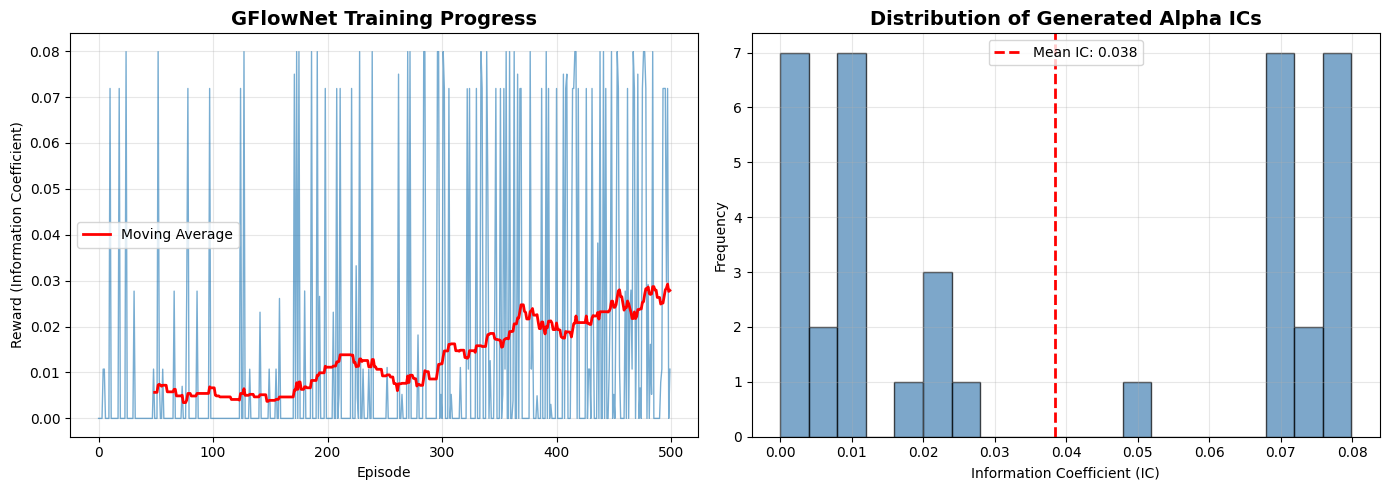


📊 Generation Statistics:
Total valid alphas generated: 38
Mean IC: 0.0384
Std IC: 0.0331
Max IC: 0.0799
Min IC: 0.0000
Diversity (unique expressions): 33


In [ ]:
# Cell 7: Visualization and Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training progress
axes[0].plot(rewards_history, alpha=0.6, linewidth=1)
axes[0].plot(pd.Series(rewards_history).rolling(50).mean(), color='red', linewidth=2, label='Moving Average')
axes[0].set_title('GFlowNet Training Progress', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward (Information Coefficient)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution of generated alphas
axes[1].hist(generated_rewards, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
mean_ic = np.mean(generated_rewards)
axes[1].axvline(mean_ic, color='red', linestyle='--', linewidth=2, label=f'Mean IC: {mean_ic:.3f}')
axes[1].set_title('Distribution of Generated Alpha ICs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Information Coefficient (IC)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('alpha_gfn_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print(f"\n📊 Generation Statistics:")
print(f"{'='*50}")
print(f"Total valid alphas generated: {len(generated_rewards)}")
print(f"Mean IC: {np.mean(generated_rewards):.4f}")
print(f"Std IC: {np.std(generated_rewards):.4f}")
print(f"Max IC: {np.max(generated_rewards):.4f}")
print(f"Min IC: {np.min(generated_rewards):.4f}")
print(f"Diversity (unique expressions): {len(set(generated_alphas))}")


**Cell 7 Analysis:**

```markdown
## Visualization & Results Summary

### Training Curve Analysis

**Observing convergence pattern:**

**Ideal pattern:** Monotonic increase with decreasing slope → plateau
**Concerning patterns:**
- High variance throughout: reward too noisy or learning rate too high
- Sudden drops: training instability or reward distribution shift
- No plateau: either need more episodes or model capacity insufficient

**Connection to optimization theory (MATH2023):**
Convergence rate depends on:
- Loss landscape curvature (Hessian eigenvalues)
- Learning rate vs gradient magnitude
- Stochasticity in gradient estimates

**Diagnostic question:** What's the effective learning rate after Adam's momentum?
```python
# Should log this during training
grad_norms = [torch.nn.utils.clip_grad_norm_(model.parameters(), float('inf'))
              for _ in training]
effective_lr = lr * grad_norms[-1] / grad_norms[0]